### Import required libraries

In [28]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import json
import time
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import mediapipe as mp
from PIL import Image

In [2]:
# Setting up plotting style
plt.style.use('default')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Mediapipe version: {mp.__version__}")

Mediapipe version: 0.10.21


### Configuration and directory setup

In [3]:
class FacialConfig:
    IMAGE_SIZE = (224, 224)
    FACE_DETECTION_CONFIDENCE = 0.5

    USE_GRAYSCALE = False

    # data augmentation settings
    ENABLE_AUGMENTATION = True
    AUGMENTATION_FACTOR = 6 # number of augmented versions per image

    # face detection settings
    FACE_PADDING = 20 # pixels to add around detected face

config = FacialConfig()

In [4]:
# Setting project directories
BASE_DIR = Path("./multimodal_facial_data")
RAW_IMAGES_DIR = BASE_DIR / "raw_facial"
PROCESSED_FACIAL_DIR = BASE_DIR / "processed_facial"
METADATA_DIR = BASE_DIR / "metadata"

for directory in [RAW_IMAGES_DIR, PROCESSED_FACIAL_DIR, METADATA_DIR]:
    directory.mkdir(parents=True, exist_ok = True)
    print(f"Created: {directory}")

Created: multimodal_facial_data/raw_facial
Created: multimodal_facial_data/processed_facial
Created: multimodal_facial_data/metadata


In [5]:
# Emotion mapping (7 emotions)
fer_emotions = {
    0: 'angry',
    1: 'disgust',
    2: 'fear',
    3: 'happy',
    4: 'sad',
    5: 'surprise',
    6: 'neutral'
}

# Emotion color mapping for visualization
emotion_colors = {
    'angry': 'red',
    'disgust': 'green',
    'fear': 'orange',
    'happy': 'yellow',
    'sad': 'blue',
    'surprise': 'pink',
    'neutral': 'gray'
}

# Reverse mapping: emotion -> code
emotion_to_code = {v: k for k, v in fer_emotions.items()}

In [6]:
# Set up logging
def get_project_logger(name):
    logger = logging.getLogger(name)
    if not logger.hasHandlers():
        handler = logging.StreamHandler()
        formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        handler.setFormatter(formatter)
        logger.setLevel(logging.INFO)
    return logger

logger = get_project_logger('facial_collector')

print(f"Emotion categories: {list(fer_emotions.values())}")
print(f"Image size: {config.IMAGE_SIZE}")
print(f"Face detection confidence threshold: {config.FACE_DETECTION_CONFIDENCE}")
print(f"Base directory: {BASE_DIR}")

Emotion categories: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
Image size: (224, 224)
Face detection confidence threshold: 0.5
Base directory: multimodal_facial_data


### Manual FER-2013 Dataset Setup

In [7]:
def setup_manual_fer2013():
    fer_base_path = RAW_IMAGES_DIR / "fer2013"

    fer_train_path = fer_base_path / "train"
    fer_test_path = fer_base_path / "test"

    dataset_info = {
        'format': 'folders',
        'samples': {},
        'emotion_found': set()
    }
    total_images = 0

    # checking training data
    if fer_train_path.exists():
        train_total = 0
        for emotion_folder in fer_train_path.iterdir():
            if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
                # Count images
                images = (list(emotion_folder.glob("*.png")) +
                          list(emotion_folder.glob("*.jpg")) +
                          list(emotion_folder.glob("*.jpeg")))
                dataset_info['samples'][f"train_{emotion_folder.name}"] = len(images)
                dataset_info['emotion_found'].add(emotion_folder.name)
                train_total += len(images)
                total_images += len(images)
                print(f" {emotion_folder.name}: {len(images)} images")

        print(f"Total train images: {train_total}")

    
    # checking testing data
    if fer_test_path.exists():
        test_total = 0
        for emotion_folder in fer_test_path.iterdir():
            if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
                # counting images
                images = (list(emotion_folder.glob("*.png")) +
                          list(emotion_folder.glob("*.jpg")) +
                          list(emotion_folder.glob("*.jpeg")))
                
                dataset_info['samples'][f"test_{emotion_folder.name}"] = len(images)
                dataset_info['emotion_found'].add(emotion_folder.name)
                test_total += len(images)
                total_images += len(images)
                print(f" {emotion_folder.name}: {len(images)} images")

        print(f"Total test images: {test_total}")

    dataset_info['total'] = total_images
    dataset_info['base_path'] = fer_base_path

    missing_emotions = set(fer_emotions.values()) - dataset_info['emotion_found']
    if missing_emotions:
        print(f"Missing emotions: {sorted(missing_emotions)}")

    return dataset_info

In [8]:
fer_dataset_info = setup_manual_fer2013()
print(f"Found {fer_dataset_info['total']} images")
print(f"Distribution: {fer_dataset_info['samples']}")
fer_ready = True
fer_format = 'folders'
fer_base_path = fer_dataset_info['base_path']

 happy: 7215 images
 disgust: 436 images
 angry: 3995 images
 surprise: 3171 images
 neutral: 4965 images
 fear: 4097 images
 sad: 4830 images
Total train images: 28709
 happy: 1774 images
 disgust: 111 images
 angry: 958 images
 surprise: 831 images
 neutral: 1233 images
 fear: 1024 images
 sad: 1247 images
Total test images: 7178
Found 35887 images
Distribution: {'train_happy': 7215, 'train_disgust': 436, 'train_angry': 3995, 'train_surprise': 3171, 'train_neutral': 4965, 'train_fear': 4097, 'train_sad': 4830, 'test_happy': 1774, 'test_disgust': 111, 'test_angry': 958, 'test_surprise': 831, 'test_neutral': 1233, 'test_fear': 1024, 'test_sad': 1247}


### Mediapipe face detection initialization

In [9]:
mp_face_detection = mp.solutions.face_detection
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [29]:
# Testing mediapipe with sample image
def test_mediapipe_detection():
    test_image = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)

    try:
        with mp_face_detection.FaceDetection(
            model_selection=0,
            min_detection_confidence = 0.5
        ) as face_detection:
            
            # converting to RGB
            rgb_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
            results = face_detection.process(rgb_image)

            if results.detections:
                print(f"Found {len(results.detections)} faces")
            else:
                print("No faces found!")
        
        return True
    
    except Exception as e:
        print(f"MediaPipe error: {e}")
        return False
    
# testing mediapipe
mediapipe_status = test_mediapipe_detection()

if mediapipe_status:
    print(f"Configuration:")
    print(f"Detection confidence: {config.FACE_DETECTION_CONFIDENCE}")
    print(f"Target image size: {config.IMAGE_SIZE}")
    print(f"Face padding: {config.FACE_PADDING}px")

else:
    print("Mediapipe failed!")

No faces found!
Configuration:
Detection confidence: 0.5
Target image size: (224, 224)
Face padding: 20px


I0000 00:00:1761942339.362054     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761942339.380087   49030 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761942339.384790   49024 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Face Detection & Cropping experiment

In [11]:
def detect_and_crop_face(image, show_visualization=True):
    try:
        # Coverting BGR to RGB
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create face detection instance
        with mp_face_detection.FaceDetection(
            model_selection = 0, # 0 for close range, 1 for far range
            min_detection_confidence = config.FACE_DETECTION_CONFIDENCE
        ) as face_detection:
            
            # Detect faces
            results = face_detection.process(rgb_image)

            if results.detections:
                detection = results.detections[0]
                bboxC = detection.location_data.relative_bounding_box

                # getting image dimensions
                h, w, _ = image.shape

                # Convert relative coordinates to pixel coordinates
                x = int(bboxC.xmin * w)
                y = int(bboxC.ymin * h)
                width = int(bboxC.width * w)
                height = int(bboxC.height * h)

                # applying padding
                padding = config.FACE_PADDING
                x = max(0, x - padding)
                width = min(w - x, width + 2 * padding)
                height = min(h - y, height + 2 * padding)

                # cropping face region
                face = image[y: y + height, x: x + width]

                # resize to standard size
                face_resized = cv2.resize(face, config.IMAGE_SIZE)

                # visualization
                if show_visualization:
                    fig, axes = plt.subplots(1, 3, figsize = (18, 6))

                    img_with_box = image.copy()
                    cv2.rectangle(img_with_box, (x, y), (x + width, y), (0, 255, 0), 2)
                    axes[0].imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
                    axes[0].set_title("Original  with Detections")
                    axes[0].axis('off')

                    # cropped face
                    axes[1].imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
                    axes[1].set_title(f'Cropped face ({face.shape[1]}x{face.shape[0]})')
                    axes[1].axis('off')

                    # resized face
                    axes[2].imshow(cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB))
                    axes[2].set_title(f'Resized face ({config.IMAGE_SIZE[0]}x{config.IMAGE_SIZE[1]})')
                    axes[2].axis('off')

                    plt.tight_layout()
                    plt.show()

                return face_resized
            else:
                if show_visualization:
                    print("No face detected in image.")
                return None
            
    except Exception as e:
        print(f"Face detection error: {e}")
        return None




I0000 00:00:1761940738.705328     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940738.712681    1931 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940738.716572    1926 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Testing face detection !!
Using sample: Training_21410769.jpg (happy)


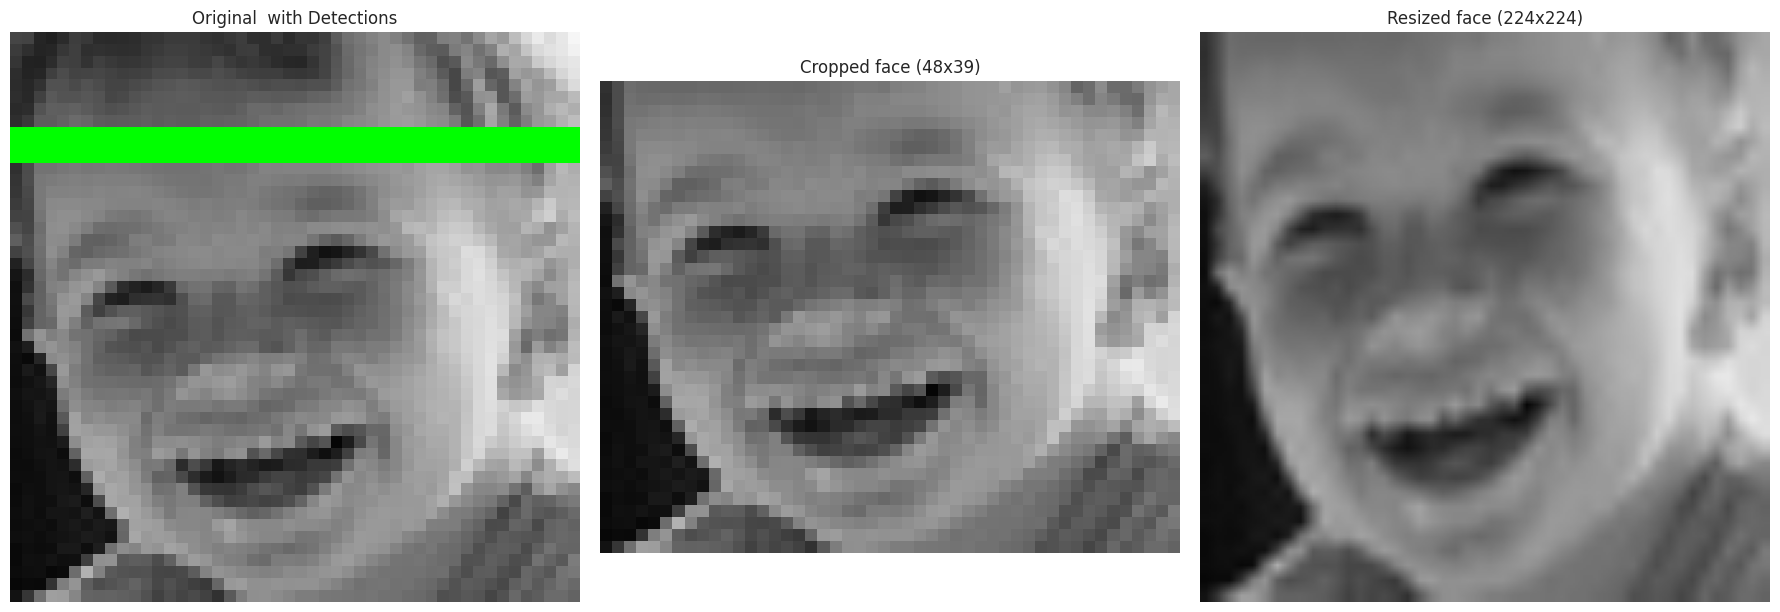

Face Detection successful
original size : (48, 48, 3)
Final size : (224, 224, 3)


In [12]:
# Testing face detection with a sample image
print("Testing face detection !!")

train_path = fer_base_path / "train"
sample_image_path = None

for emotion_folder in train_path.iterdir():
    if emotion_folder.is_dir():
        images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
        if images:
            sample_image_path = images[0]
            emotion_name = emotion_folder.name
            break

if sample_image_path:
    print(f"Using sample: {sample_image_path.name} ({emotion_name})")

    # load and test
    sample_image = cv2.imread(str(sample_image_path))
    if sample_image is not None:
        cropped_face = detect_and_crop_face(sample_image, show_visualization=True)
        
        if cropped_face is not None:
            print(f"Face Detection successful")
            print(f"original size : {sample_image.shape}")
            print(f"Final size : {cropped_face.shape}")
        else:
            print("face detection failed!")
        
    else:
        print("could not load sample image!")

else:
    print("No sample image found")

### Facial Landmark Extraction experiment

In [13]:
# using mediapipe face Mesh
def extract_facial_landmark(face_image, show_visualization=True):
    try:
        rgb_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB)

        # Create face mesh instance
        with mp_face_mesh.FaceMesh(
            static_image_mode = True,
            max_num_faces = 1,
            refine_landmarks = True,
            min_detection_confidence = 0.5
        ) as face_mesh:
            
            results = face_mesh.process(rgb_image)

            if results.multi_face_landmarks:
                landmarks = []
                face_landmarks = results.multi_face_landmarks[0]

                for landmark in face_landmarks.landmark:
                    # store x, y, z coordinates
                    landmarks.extend([landmark.x, landmark.y, landmark.z])
                
                landmark_array = np.array(landmarks)

                # visualization
                if show_visualization:
                    annotated_image = face_image.copy()
                    mp_drawing.draw_landmarks(
                        image = annotated_image,
                        landmark_list = face_landmarks,
                        connections = mp_face_mesh.FACEMESH_TESSELATION,
                        landmark_drawing_spec = None,
                        connection_drawing_spec = mp_drawing_styles.get_default_face_mesh_tesselation_style()
                    )

                    # display 
                    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
                    axes[0].imshow(cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB))
                    axes[0].set_title('Original Face')
                    axes[0].axis('off')

                    axes[1].imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
                    axes[1].set_title('With 478 facial landmarks')
                    axes[1].axis('off')

                    plt.tight_layout()
                    plt.show()

                    print("Landmark Statistics:")
                    print("Total landmarks: 478 and coordinates per landmark: 3(x, y, z)")
                    print(f"Total features: {len(landmark_array)}")
                    print(f"Shape: {landmark_array.shape}")
                    print(f"Sample values: {landmark_array[:9]}")  # first 3 landmarks

                return landmark_array

            else:
                if show_visualization:
                    print("No facial landmarks detected")
                return None
    
    except Exception as e:
        print(f" Error extracted landmarks: {e}")
        return None


 Using happy sample: Training_21410769.jpg


I0000 00:00:1761942353.632099     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761942353.637325   49079 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761942353.640069   49073 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761942353.649477     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761942353.654122   49111 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761942353.657179   49084 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761942353.671030   49087 inference_feedback_manager.cc:114] Feedback manager requ

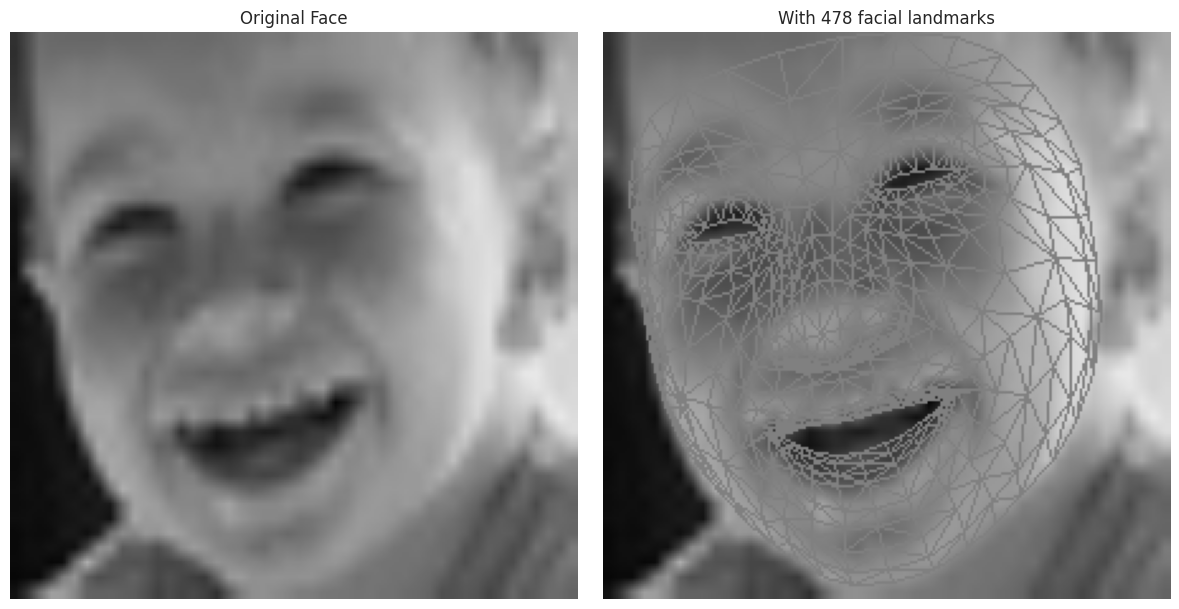

Landmark Statistics:
Total landmarks: 478 and coordinates per landmark: 3(x, y, z)
Total features: 1434
Shape: (1434,)
Sample values: [ 0.42492539  0.66254818 -0.10308881  0.39357334  0.5703944  -0.18841229
  0.41347602  0.59431958 -0.10881869]
Successfully extracted 1434 landmark coordinates.


In [30]:
# Testing landmark extraction 
train_path = fer_base_path / 'train'

happy_path = train_path / 'happy'
if happy_path.exists():
    images = list(happy_path.glob("*.jpg")) + list(happy_path.glob("*.png"))
    if images:
        sample_path = images[0]
        print(f" Using happy sample: {sample_path.name}")

        sample_image = cv2.imread(str(sample_path))
        if sample_image is not None:
            cropped_face = detect_and_crop_face(sample_image, show_visualization=False)

            if cropped_face is not None:
                landmarks = extract_facial_landmark(cropped_face, show_visualization=True)

                if landmarks is not None:
                    print(f"Successfully extracted {len(landmarks)} landmark coordinates.")
                else:
                    print("Landmark extraction failed")
            else:
                print("face detection failed")
        else:
            print("Can't load sample image.")

    else:
        print("Happy image not found")

else:
    print("Folder not found!")


### Image augmentation

In [15]:
def augment_facial_image(image):
    augmented = []

    # original image
    augmented.append(('original', image))

    # horizontal flip
    flipped = cv2.flip(image, 1)
    augmented.append(('flipped', flipped))

    # brightness adjustments
    bright = np.clip(image * 1.2, 0, 1) 
    augmented.append(('bright', bright))

    dark = np.clip(image * 0.8, 0, 1)
    augmented.append(('dark', dark))

    # Contrast adjustment
    contrast = np.clip((image - 0.5) * 1.3 + 0.5, 0, 1)
    augmented.append(('contrast', contrast))

    # Slight rotation
    h, w = image.shape[:2]
    center = (w // 2, h//2)

    # Rotate +5 degree
    M1 = cv2.getRotationMatrix2D(center, 5, 1.0)
    rotated_pos = cv2.warpAffine(image, M1, (w, h))
    augmented.append(('rotated_+5', rotated_pos))

    # Rotate -5 degree
    M2 = cv2.getRotationMatrix2D(center, -5, 1.0)
    rotated_neg = cv2.warpAffine(image, M2, (w, h))
    augmented.append(('rotated_-5', rotated_neg))

    # Gaussian noise
    noise = np.random.normal(0, 0.02, image.shape)
    noisy = np.clip(image + noise, 0, 1)
    augmented.append(('noisy', noisy))

    # Gaussian blur
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    augmented.append(('blurred', blurred))

    return augmented

Using angry sample: Training_36072885.jpg


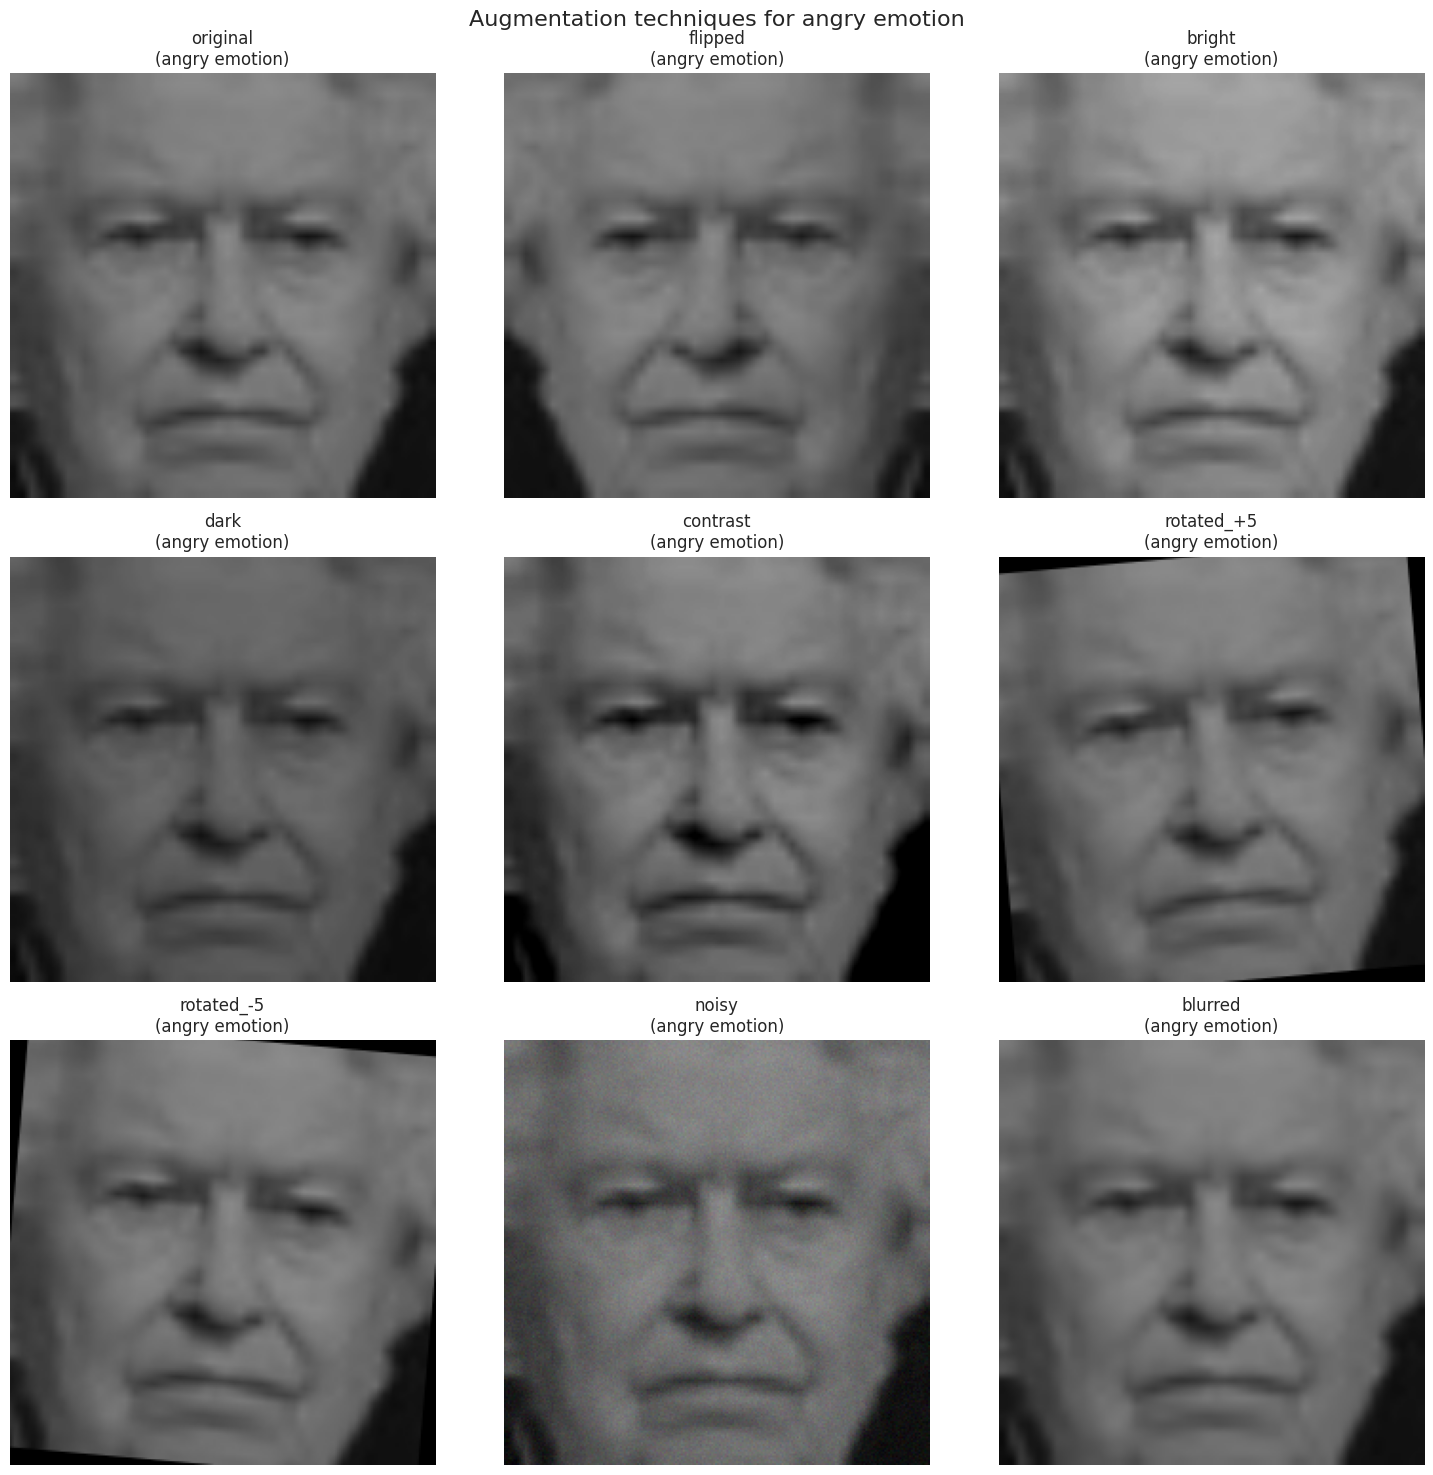

Generated 9 augmented versions
Augmentation types: ['original', 'flipped', 'bright', 'dark', 'contrast', 'rotated_+5', 'rotated_-5', 'noisy', 'blurred']
Using happy sample: Training_21410769.jpg
Generated 9 augmented version


In [16]:
# Testing augmentation
train_path = fer_base_path / "train"
angry_path = train_path / "angry"

images = list(angry_path.glob("*.jpg")) + list(angry_path.glob("*.png"))
sample_path = images[0]
print(f"Using angry sample: {sample_path.name}")

# Load and preprocess
image = cv2.imread(str(sample_path))
if image is not None:
    image_resized = cv2.resize(image, config.IMAGE_SIZE)
    image_normalized = image_resized.astype(np.float32) / 255.0

    # Apply augmentations
    augmented_images = augment_facial_image(image_normalized)

    # visualization of augmentations
    n_augmentation = len(augmented_images)
    cols = 3
    rows = (n_augmentation + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize = (15, rows * 5))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    

    for idx, (aug_name, aug_image) in enumerate(augmented_images):
        axes[idx].imshow(cv2.cvtColor((aug_image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[idx].set_title(f"{aug_name}\n(angry emotion)")
        axes[idx].axis('off')

    plt.suptitle('Augmentation techniques for angry emotion', fontsize=16)
    plt.tight_layout()
    plt.show()

    print(f"Generated {len(augmented_images)} augmented versions")
    print(f"Augmentation types: {[name for name, _ in augmented_images]}")

else:
    print("Could not load image")

# Try any available emotion
for emotion_folder in train_path.iterdir():
    if emotion_folder.is_dir():
        images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
        if images:
            sample_path = images[0]
            emotion_name = emotion_folder.name
            print(f"Using {emotion_name} sample: {sample_path.name}")

            image = cv2.imread(str(sample_path))
            image_resized = cv2.resize(image, config.IMAGE_SIZE)
            image_normalized = image_resized.astype(np.float32) / 255.0
            augmented_images = augment_facial_image(image_normalized)

            print(f"Generated {len(augmented_images)} augmented version")

            break


### Single image processing pipeline

In [17]:
def preprocess_single_facial_image(image_path, emotion_label, show_steps=True):
    try:
        # loading image
        if isinstance(image_path, (str, Path)):
            image = cv2.imread(str(image_path))
            
        else:
            image = image_path.copy()

        image_resized = cv2.resize(image, config.IMAGE_SIZE)

        image_normalized = image_resized.astype(np.float32) / 255.0

        landmarks = extract_facial_landmark(image_resized, show_visualization=False)

        # Applying augmentation
        if config.ENABLE_AUGMENTATION:
            augmented = augment_facial_image(image_normalized)
        else:
            augmented = [('original', image_normalized)]

        # Visualization
        fig, axes = plt.subplots(1, 4, figsize = (16, 4))
        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Original\n({image.shape[0]} X {image.shape[1]})")
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Resized\n({config.IMAGE_SIZE[0]} x {config.IMAGE_SIZE[1]})')
        axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor((image_normalized * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[2].set_title('Normalized (0-1 range)')
        axes[2].axis('off')

        axes[3].text(0.1, 0.5, f"Emotion: {emotion_label}\n\n"
                                f"Landmarks: {len(landmarks) if landmarks is not None else 0}\n\n"
                                f"Augmentations: {len(augmented)}\n\n"
                                f"Final shape: {image_normalized.shape}",
                                fontsize = 12, verticalalignment = 'center')
        axes[3].axis('off')

        plt.suptitle(f"Processing pipeline for {emotion_label.upper()} emotion", fontsize=14)
        plt.tight_layout()
        plt.show()

        return {
            'image': image_normalized,
            'landmarks': landmarks,
            'emotion': emotion_label,
            'augmented': augmented,
            'image_shape': image_normalized.shape,
            'has_landmarks': landmarks is not None
        }
    except Exception as e:
        print(f"Error in preprocessing: {e}")
        return None

Testing with: Training_21410769.jpg (happy)


I0000 00:00:1761940739.397158     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940739.401691    2006 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940739.403173    1979 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940739.417754    1981 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


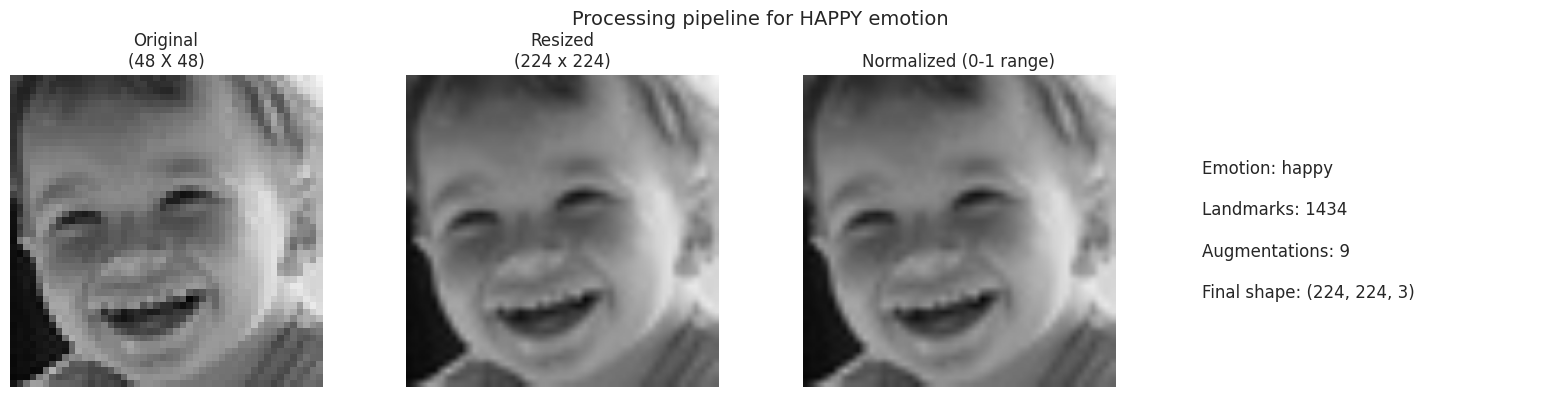

Preprocessing successful!
Results:
 Emotin: happy
 Image shape: (224, 224, 3)
 Landmarks: 1434
 Augmentations: 9


In [18]:
# Testing pipeline
train_path = fer_base_path / "train"
surprise_path = train_path / "surprise"

sample_path = None
emotion_name = None

for emotin_folder in train_path.iterdir():
    if emotion_folder.is_dir():
        images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
        if images:
            sample_path = images[0]
            emotion_name = emotion_folder.name
            break

if sample_path and emotion_name:
    print(f"Testing with: {sample_path.name} ({emotion_name})")
    processed = preprocess_single_facial_image(sample_path, emotion_name, show_steps=True)

    print(f"Preprocessing successful!")
    print("Results:")
    print(f" Emotin: {processed['emotion']}")
    print(f" Image shape: {processed['image'].shape}")
    print(f" Landmarks: {len(processed['landmarks']) if processed['landmarks'] is not None else 'None'}")
    print(f" Augmentations: {len(processed['augmented'])}")


else:
    print("No sample images found")

### Batch Processing experiment

In [19]:
# processing multiple folders from different emotions
def batch_process_folders(sample_size=5):
    train_path = fer_base_path / "train"

    # Get samples from each emotion
    emotion_samples = {}
    for emotion_folder in train_path.iterdir():
        if emotion_folder.is_dir() and emotion_folder.name in fer_emotions.values():
            images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))
            if images:
                sample_count = min(sample_size, len(images))
                selected_images = np.random.choice(images, sample_count, replace=False)
                emotion_samples[emotion_folder.name] = selected_images

    print("Selected samples are:")
    for emotion, samples in emotion_samples.items():
        print(f" {emotion}: {len(samples)} samples")

    # processing all samples
    all_processed = []

    for emotion, sample_paths in emotion_samples.items():
        for idx, img_path in enumerate(tqdm(sample_paths, desc=emotion)):
            try:
                processed = preprocess_single_facial_image(img_path, emotion, show_steps=False)
                if processed:
                    processed['emotion_code'] = emotion_to_code.get(emotion, -1)
                    processed['split'] = 'train'
                    processed['original_path'] = str(img_path)
                    all_processed.append(processed)

            except Exception as e:
                print(f"Error processing {img_path.name}: {e}")
                continue

        processed_count = len([p for p in all_processed if p['emotion'] == emotion])
        print(f"Processed {processed_count} {emotion} samples")

    return all_processed



Selected samples are:
 happy: 3 samples
 disgust: 3 samples
 angry: 3 samples
 surprise: 3 samples
 neutral: 3 samples
 fear: 3 samples
 sad: 3 samples


happy:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761940739.753397     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940739.757759    2036 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940739.760158    2011 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940739.775633    2013 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


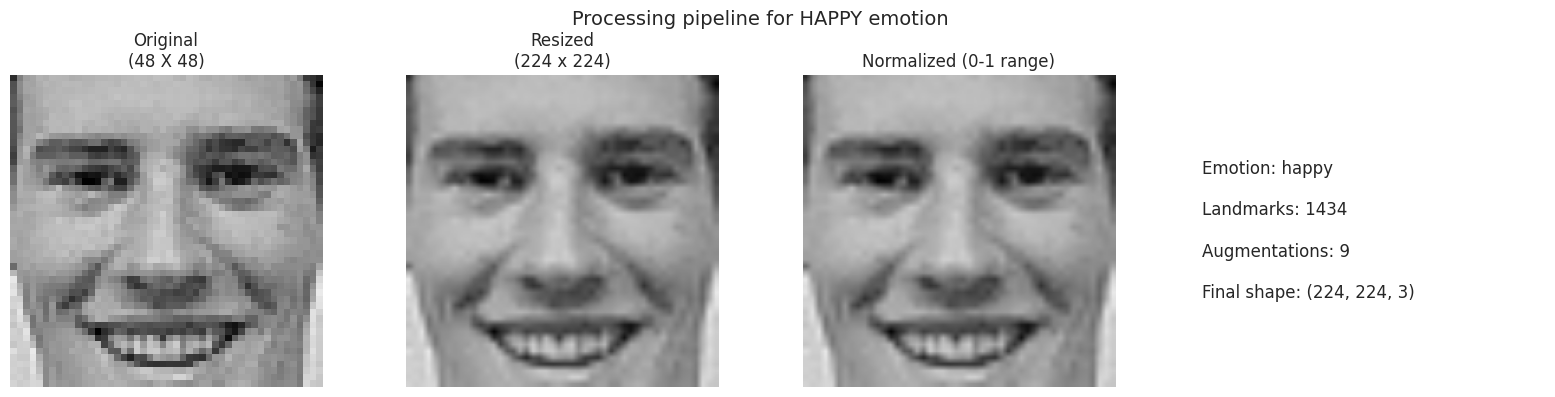

happy:  33%|███▎      | 1/3 [00:00<00:00,  6.21it/s]I0000 00:00:1761940739.914814     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940739.920749    2065 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940739.924614    2038 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940739.938257    2060 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


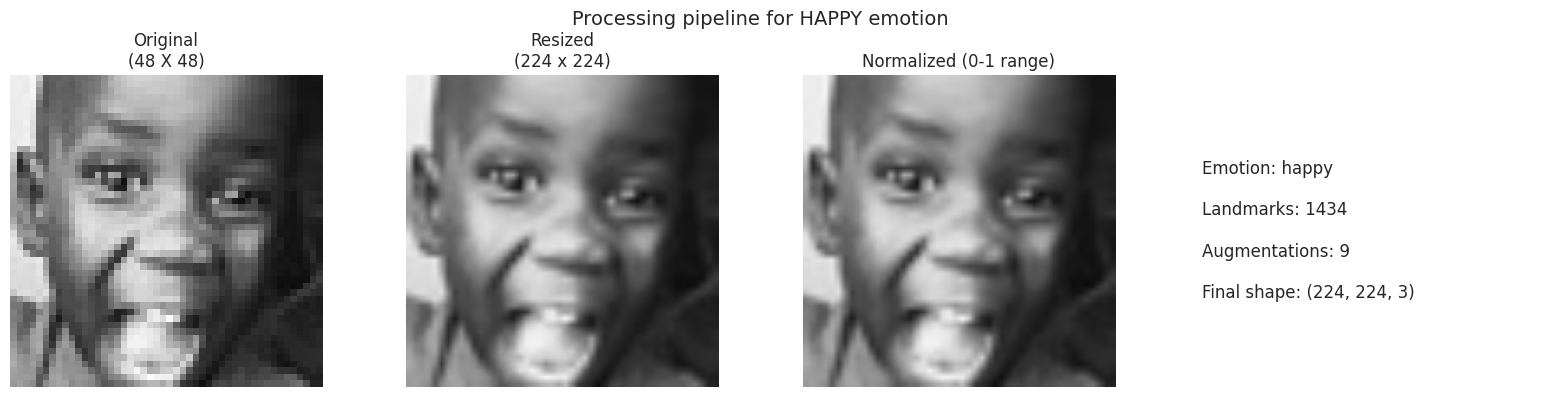

happy:  67%|██████▋   | 2/3 [00:00<00:00,  6.21it/s]I0000 00:00:1761940740.075532     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940740.081278    2094 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940740.084150    2069 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940740.096303    2090 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


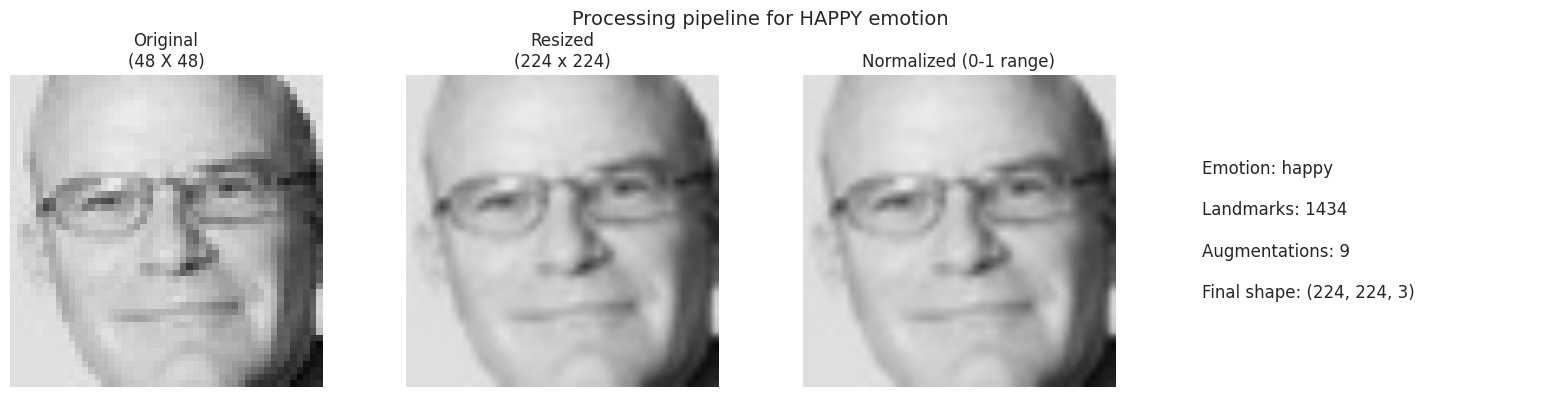

happy: 100%|██████████| 3/3 [00:00<00:00,  6.21it/s]


Processed 3 happy samples


disgust:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761940740.238402     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940740.245010    2123 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940740.249101    2097 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940740.263153    2095 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


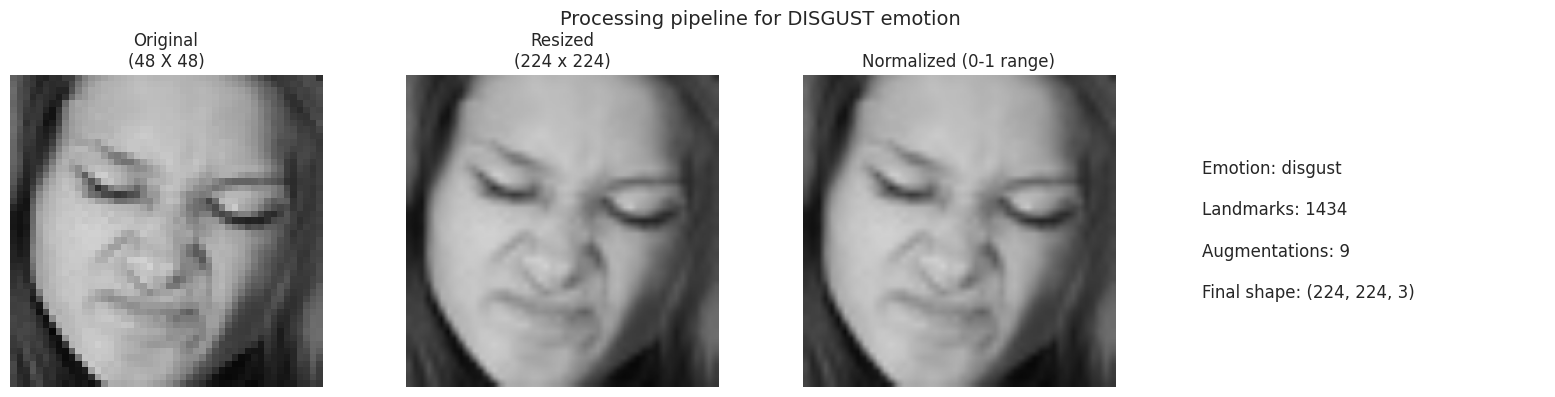

disgust:  33%|███▎      | 1/3 [00:00<00:00,  6.10it/s]I0000 00:00:1761940740.401585     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940740.407256    2152 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940740.408792    2130 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940740.424599    2125 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


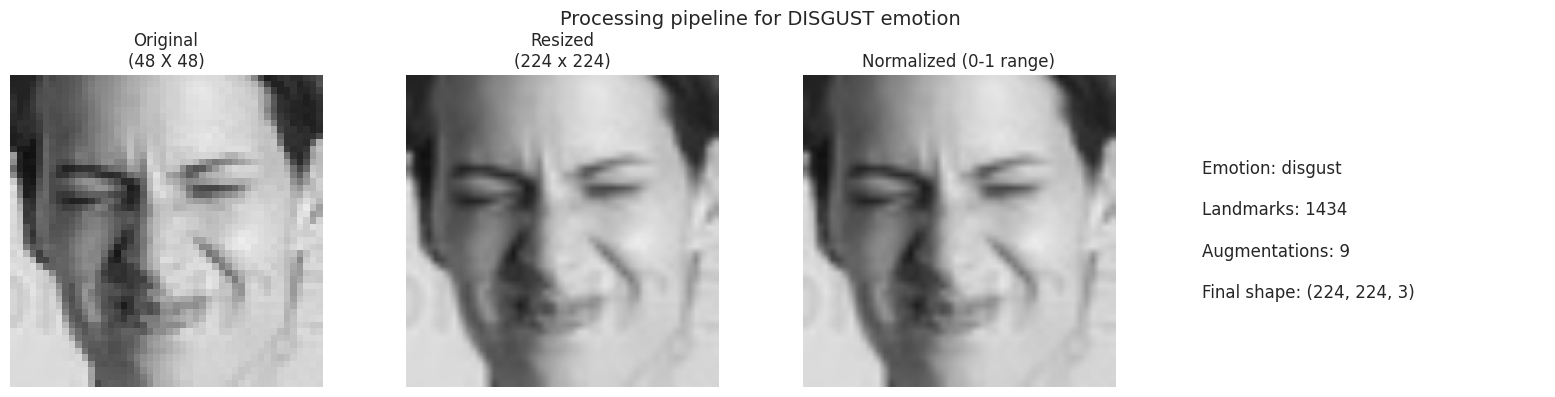

disgust:  67%|██████▋   | 2/3 [00:00<00:00,  6.21it/s]I0000 00:00:1761940740.560731     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940740.565868    2181 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940740.567044    2155 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940740.582246    2154 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


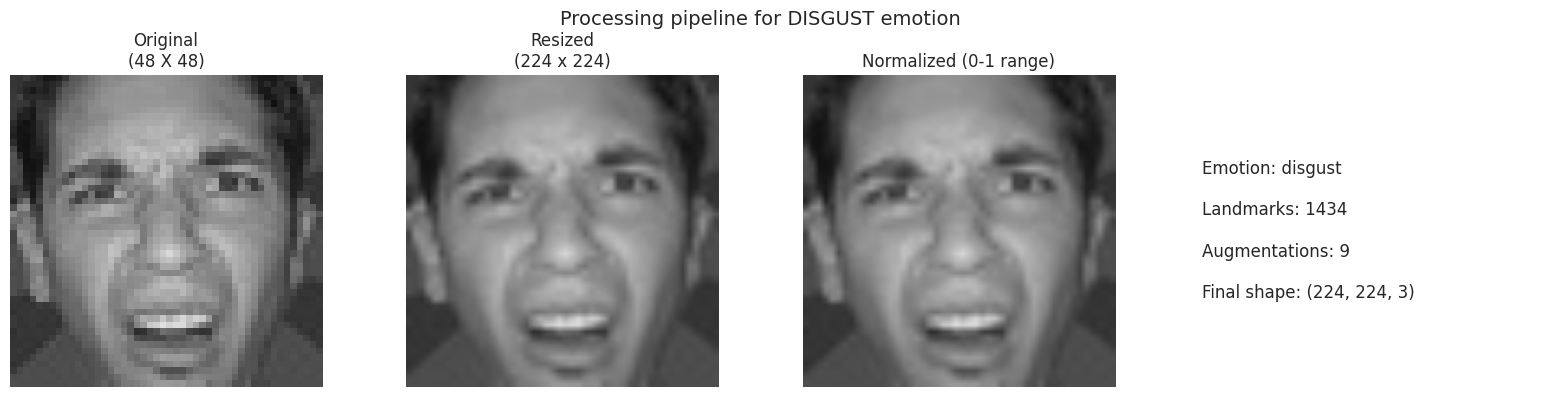

disgust: 100%|██████████| 3/3 [00:00<00:00,  6.06it/s]


Processed 3 disgust samples


angry:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761940740.735057     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940740.740925    2216 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940740.742214    2191 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940740.758775    2192 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


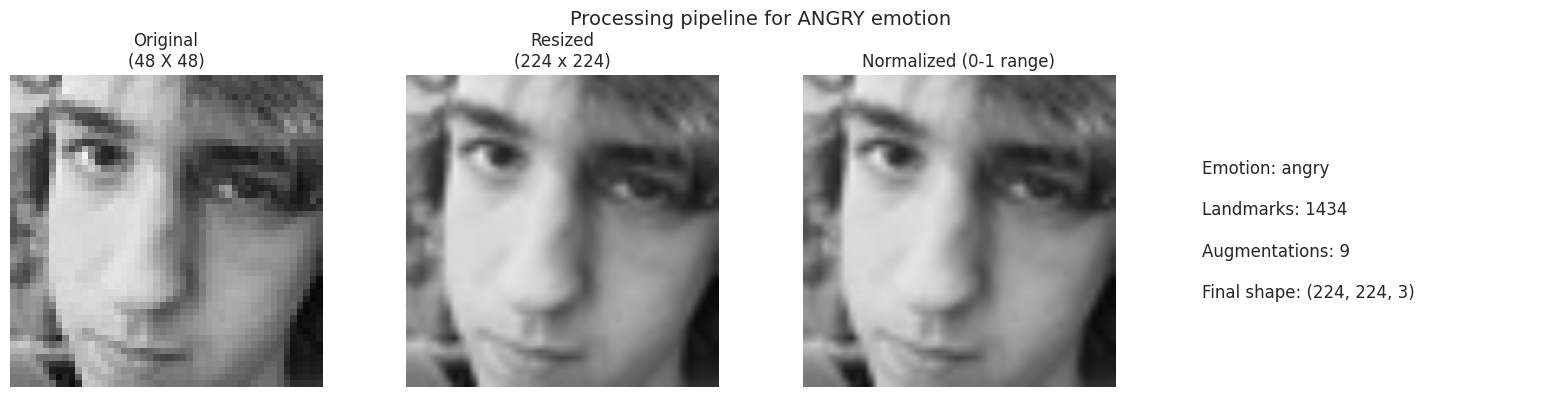

angry:  33%|███▎      | 1/3 [00:00<00:00,  6.22it/s]I0000 00:00:1761940740.895495     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940740.901472    2245 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940740.902908    2217 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940740.910713    2239 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


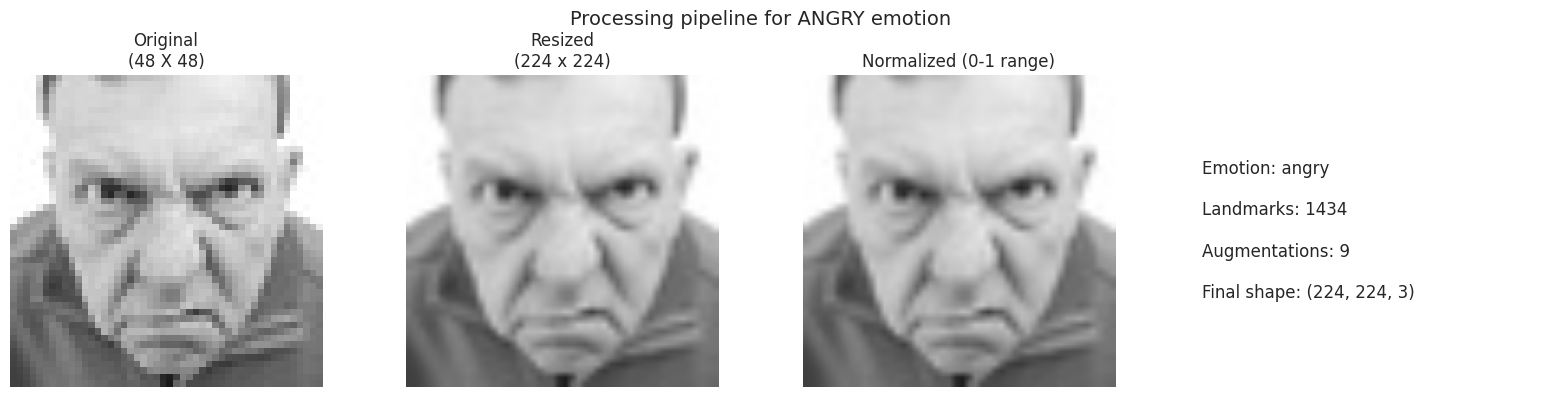

angry:  67%|██████▋   | 2/3 [00:00<00:00,  6.38it/s]I0000 00:00:1761940741.049199     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940741.055571    2274 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940741.063550    2249 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940741.075808    2250 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


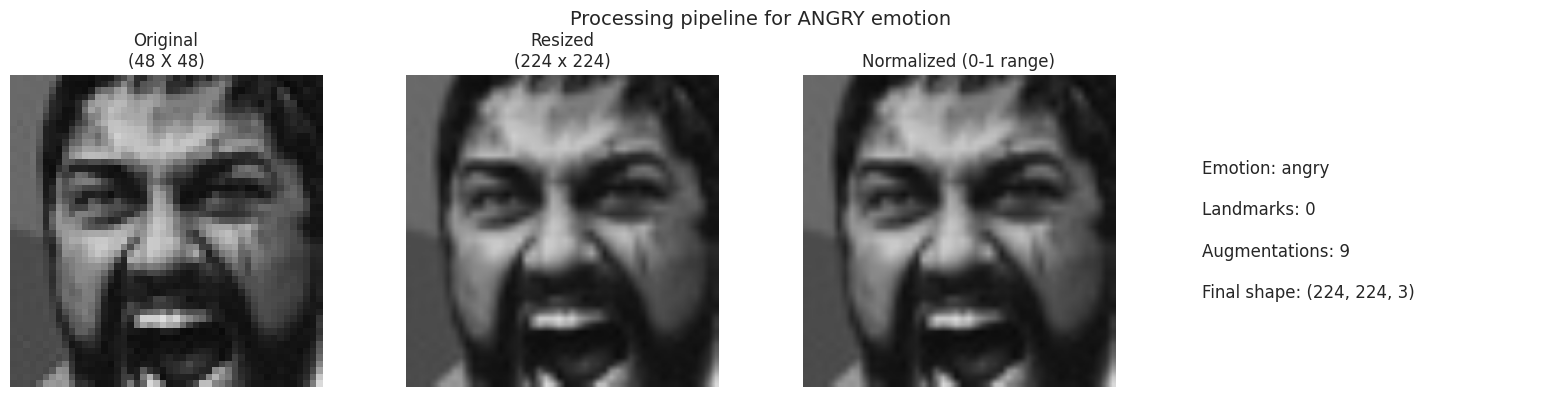

angry: 100%|██████████| 3/3 [00:00<00:00,  6.23it/s]


Processed 3 angry samples


surprise:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761940741.218323     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940741.223640    2303 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940741.225294    2276 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940741.238137    2301 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


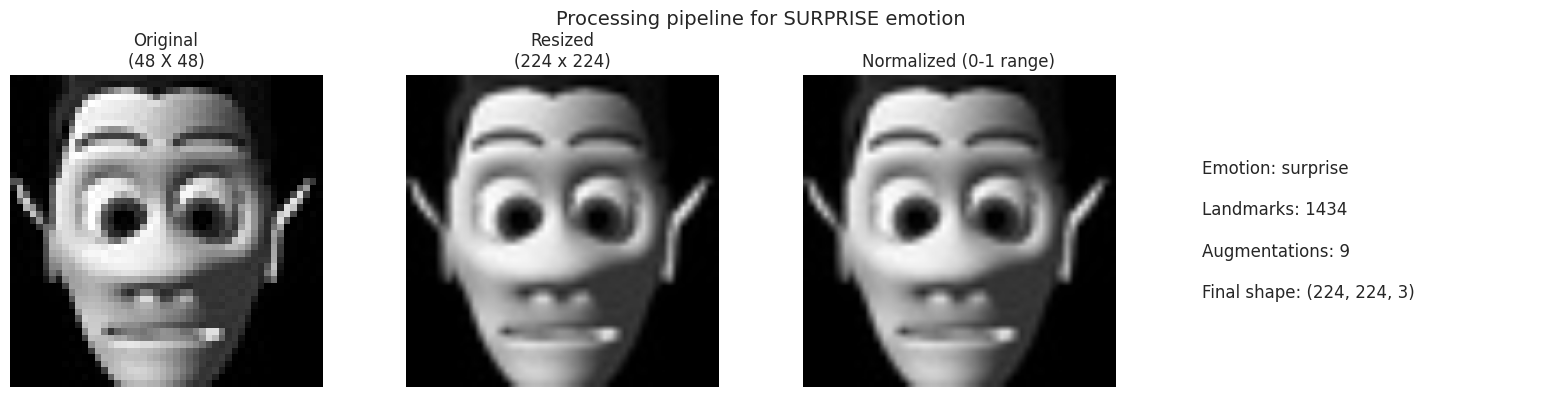

surprise:  33%|███▎      | 1/3 [00:00<00:00,  6.20it/s]I0000 00:00:1761940741.380315     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940741.385448    2332 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940741.388733    2307 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940741.396126    2305 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


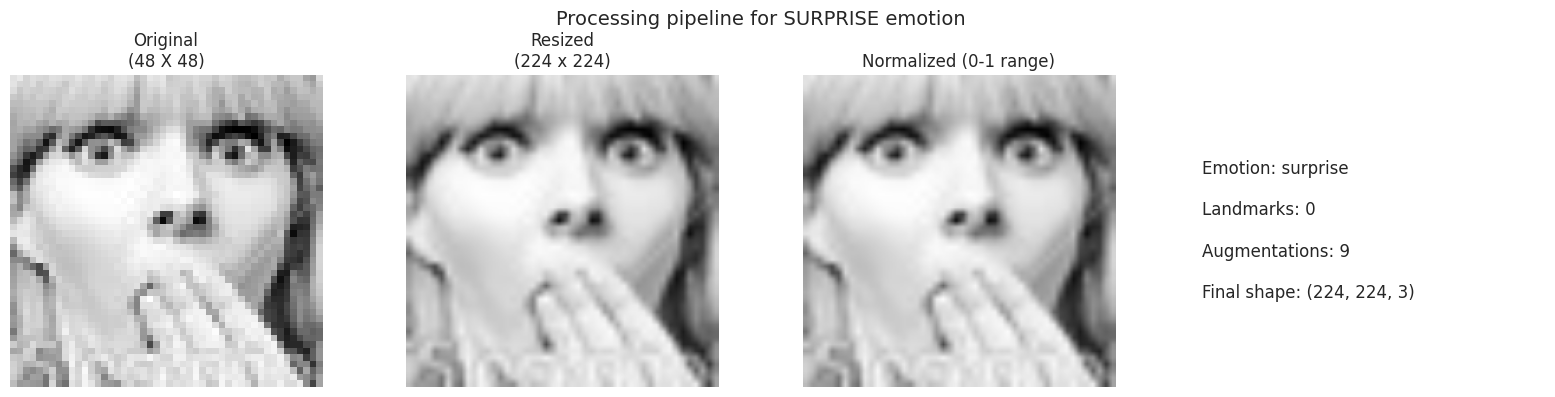

surprise:  67%|██████▋   | 2/3 [00:00<00:00,  6.13it/s]I0000 00:00:1761940741.544335     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940741.551512    2361 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940741.555255    2334 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940741.572187    2333 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


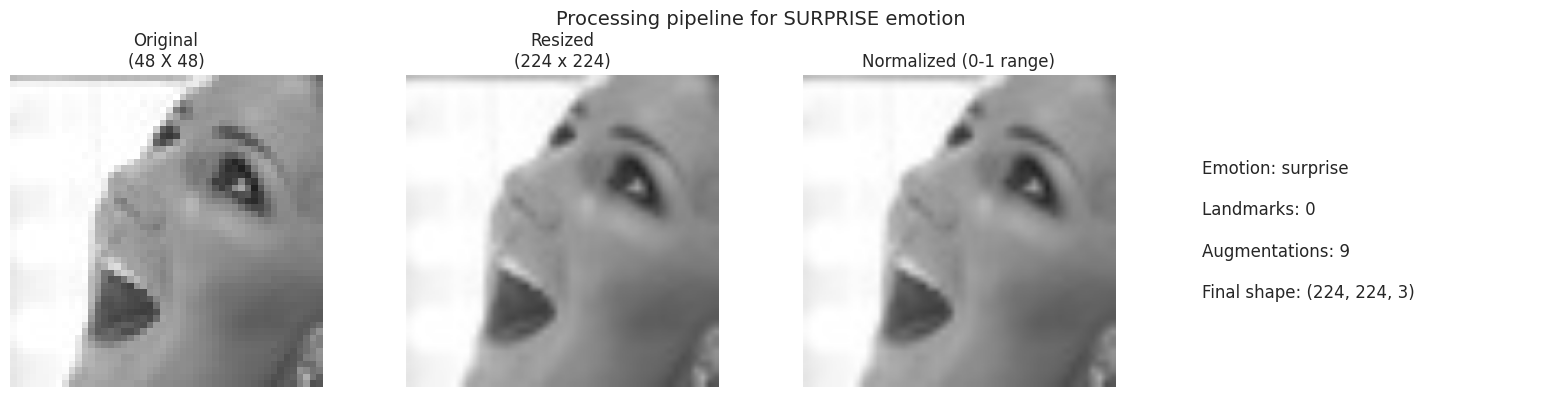

surprise: 100%|██████████| 3/3 [00:00<00:00,  6.15it/s]


Processed 3 surprise samples


neutral:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761940741.707009     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940741.712482    2390 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940741.713866    2365 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940741.730651    2362 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


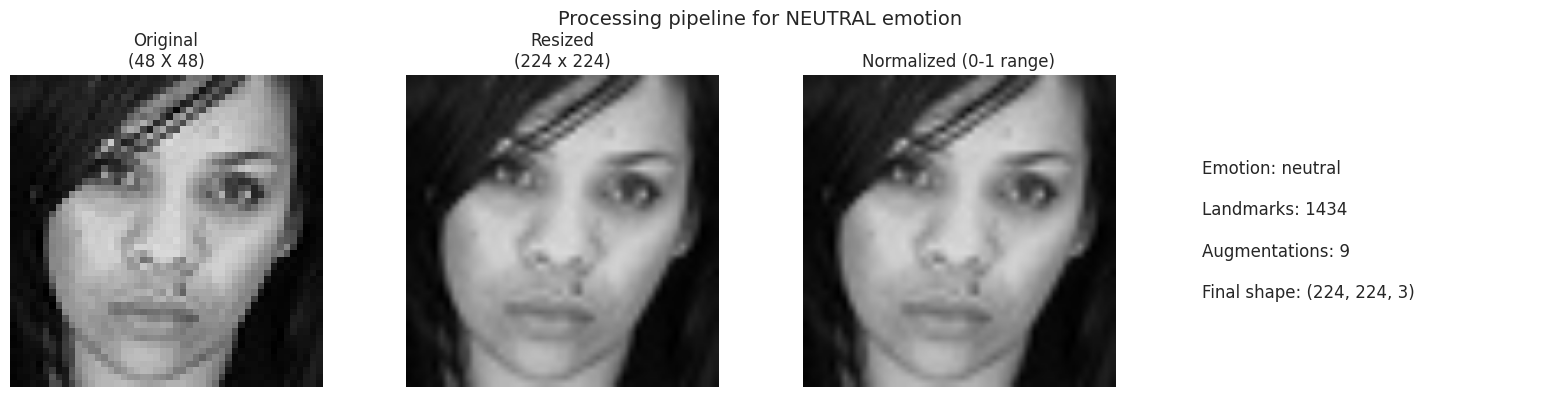

neutral:  33%|███▎      | 1/3 [00:00<00:00,  5.93it/s]I0000 00:00:1761940741.876849     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940741.882396    2419 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940741.883703    2397 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940741.894490    2395 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


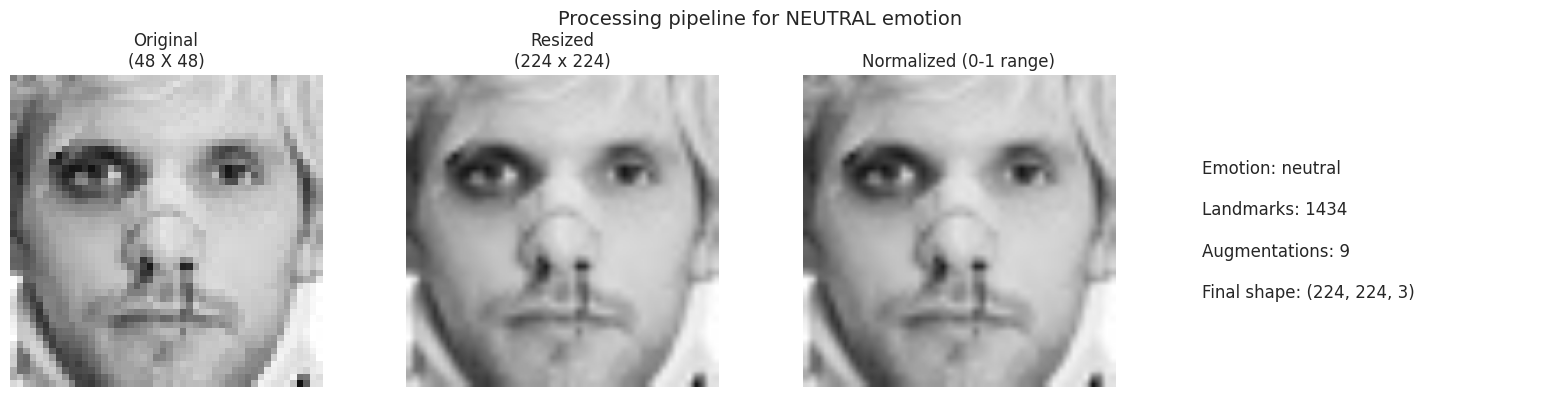

neutral:  67%|██████▋   | 2/3 [00:00<00:00,  4.21it/s]I0000 00:00:1761940742.162626     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940742.167944    2448 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940742.169758    2432 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940742.183660    2421 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


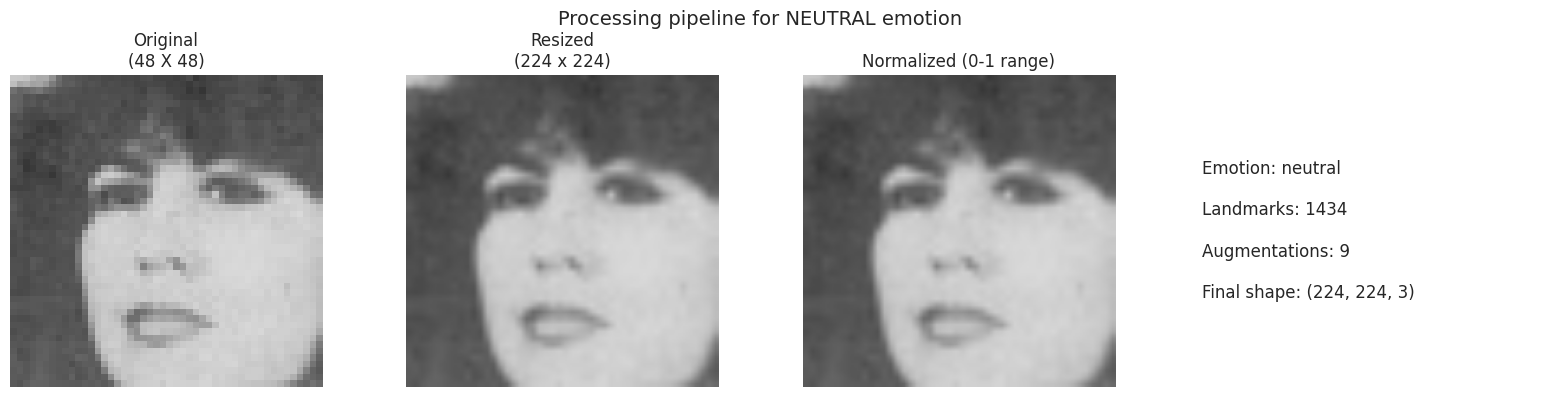

neutral: 100%|██████████| 3/3 [00:00<00:00,  4.95it/s]


Processed 3 neutral samples


fear:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761940742.316031     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940742.320772    2477 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940742.322773    2449 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940742.338230    2450 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


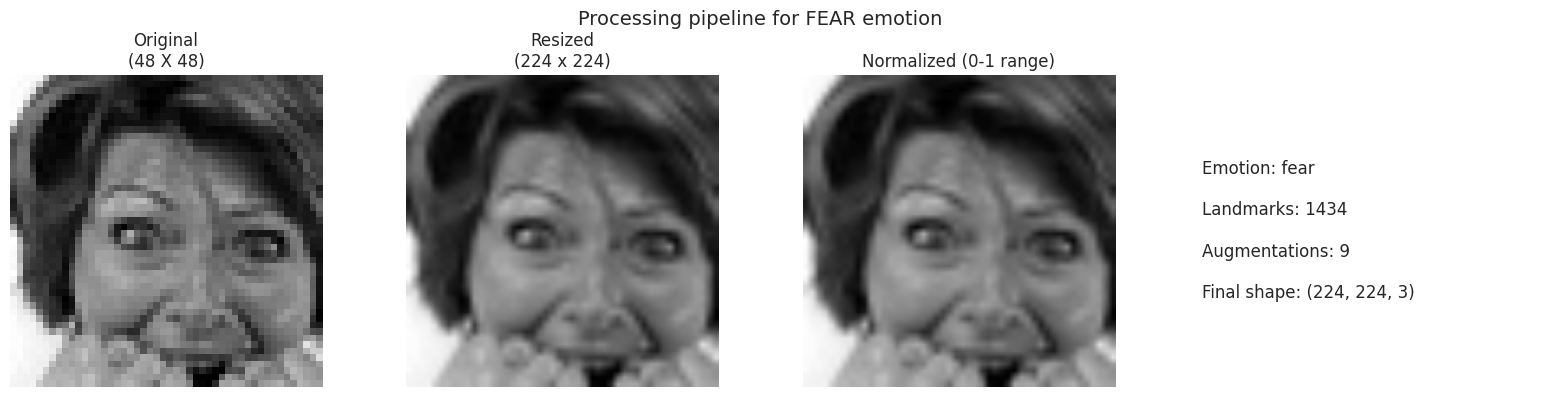

fear:  33%|███▎      | 1/3 [00:00<00:00,  6.04it/s]I0000 00:00:1761940742.482513     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940742.487745    2506 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940742.489143    2480 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940742.504333    2478 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


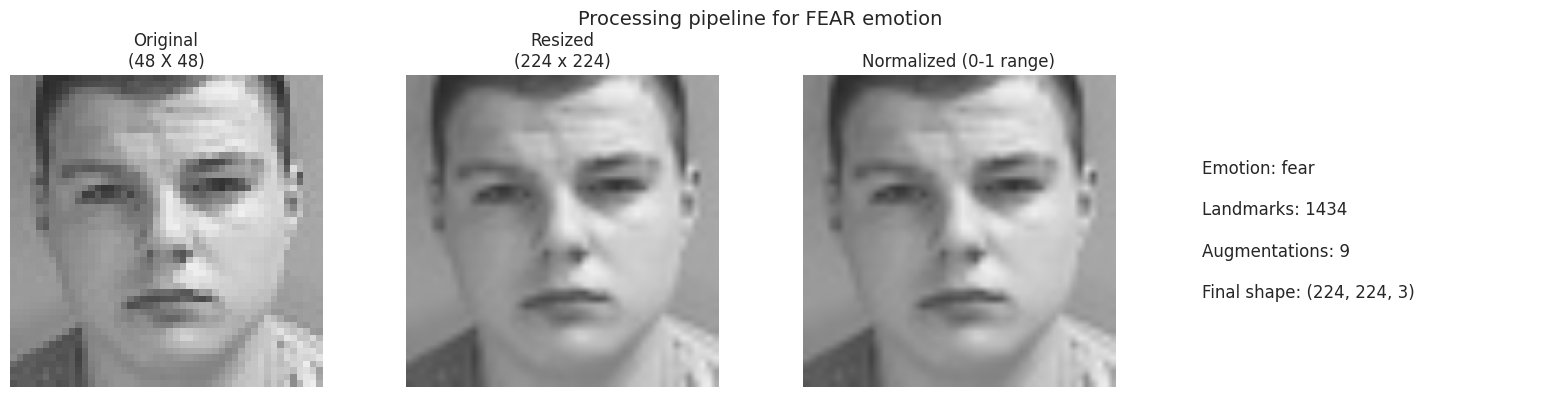

fear:  67%|██████▋   | 2/3 [00:00<00:00,  6.20it/s]I0000 00:00:1761940742.640512     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940742.645471    2535 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940742.646762    2515 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940742.657452    2507 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


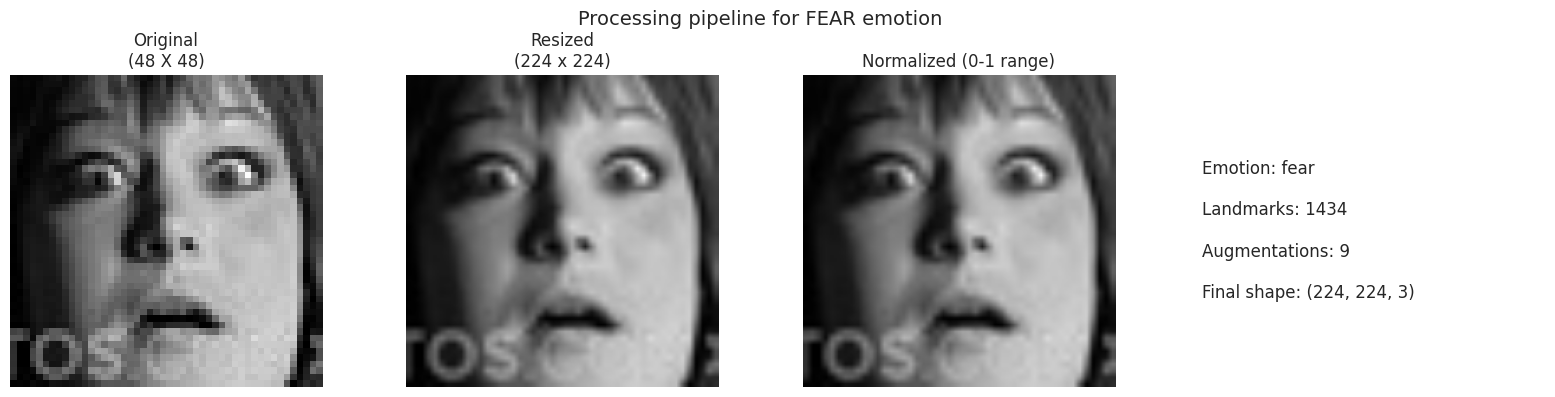

fear: 100%|██████████| 3/3 [00:00<00:00,  6.07it/s]


Processed 3 fear samples


sad:   0%|          | 0/3 [00:00<?, ?it/s]I0000 00:00:1761940742.812159     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940742.816644    2570 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940742.818090    2549 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940742.827566    2566 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


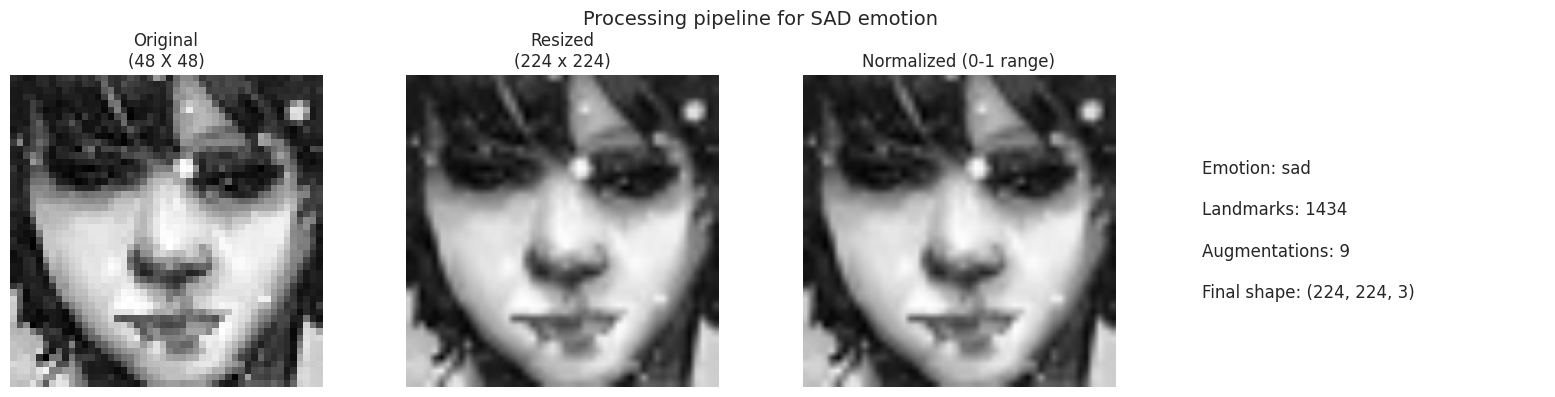

sad:  33%|███▎      | 1/3 [00:00<00:00,  6.21it/s]I0000 00:00:1761940742.973442     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940742.977808    2599 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940742.979444    2577 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940742.988416    2576 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


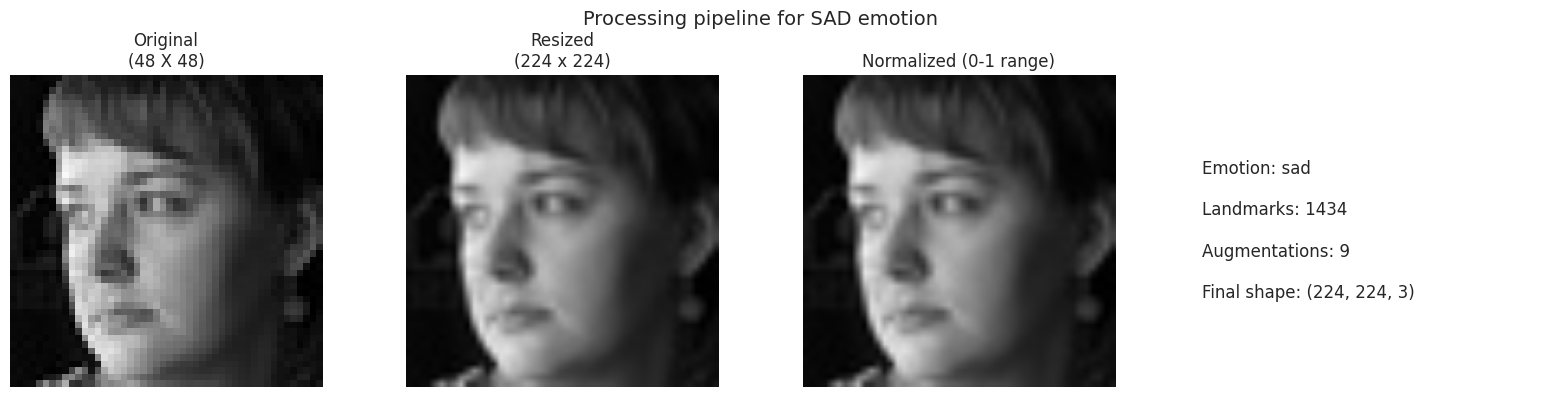

sad:  67%|██████▋   | 2/3 [00:00<00:00,  6.13it/s]I0000 00:00:1761940743.138232     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940743.142940    2628 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940743.148304    2601 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940743.161100    2603 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


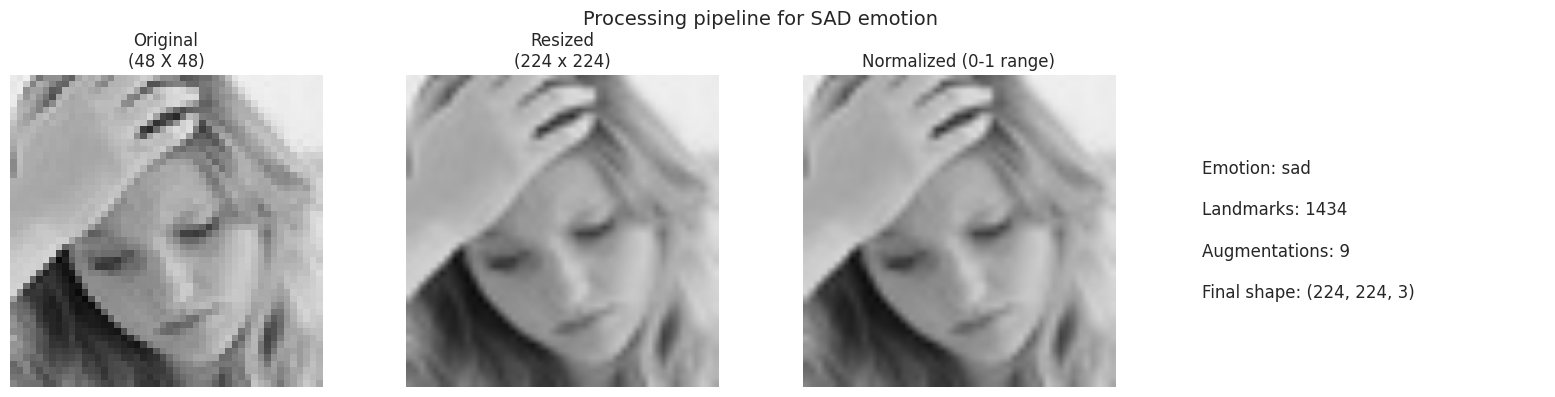

sad: 100%|██████████| 3/3 [00:00<00:00,  6.11it/s]

Processed 3 sad samples
Batch Processing complete
Total processed: 21 samples
 Distribution: {'happy': 3, 'disgust': 3, 'angry': 3, 'surprise': 3, 'neutral': 3, 'fear': 3, 'sad': 3}


In [20]:
# run batch processing
batch_processed = batch_process_folders(sample_size=3)

print("Batch Processing complete")
print(f"Total processed: {len(batch_processed)} samples")

# emotion_distribution
emotion_dist = {}
for item in batch_processed:
    emotion = item['emotion']
    emotion_dist[emotion] = emotion_dist.get(emotion, 0) + 1

print(f" Distribution: {emotion_dist}")

# Storing the later use
BATCH_PROCESSED_DATA = batch_processed

### Feature visualization & analysis

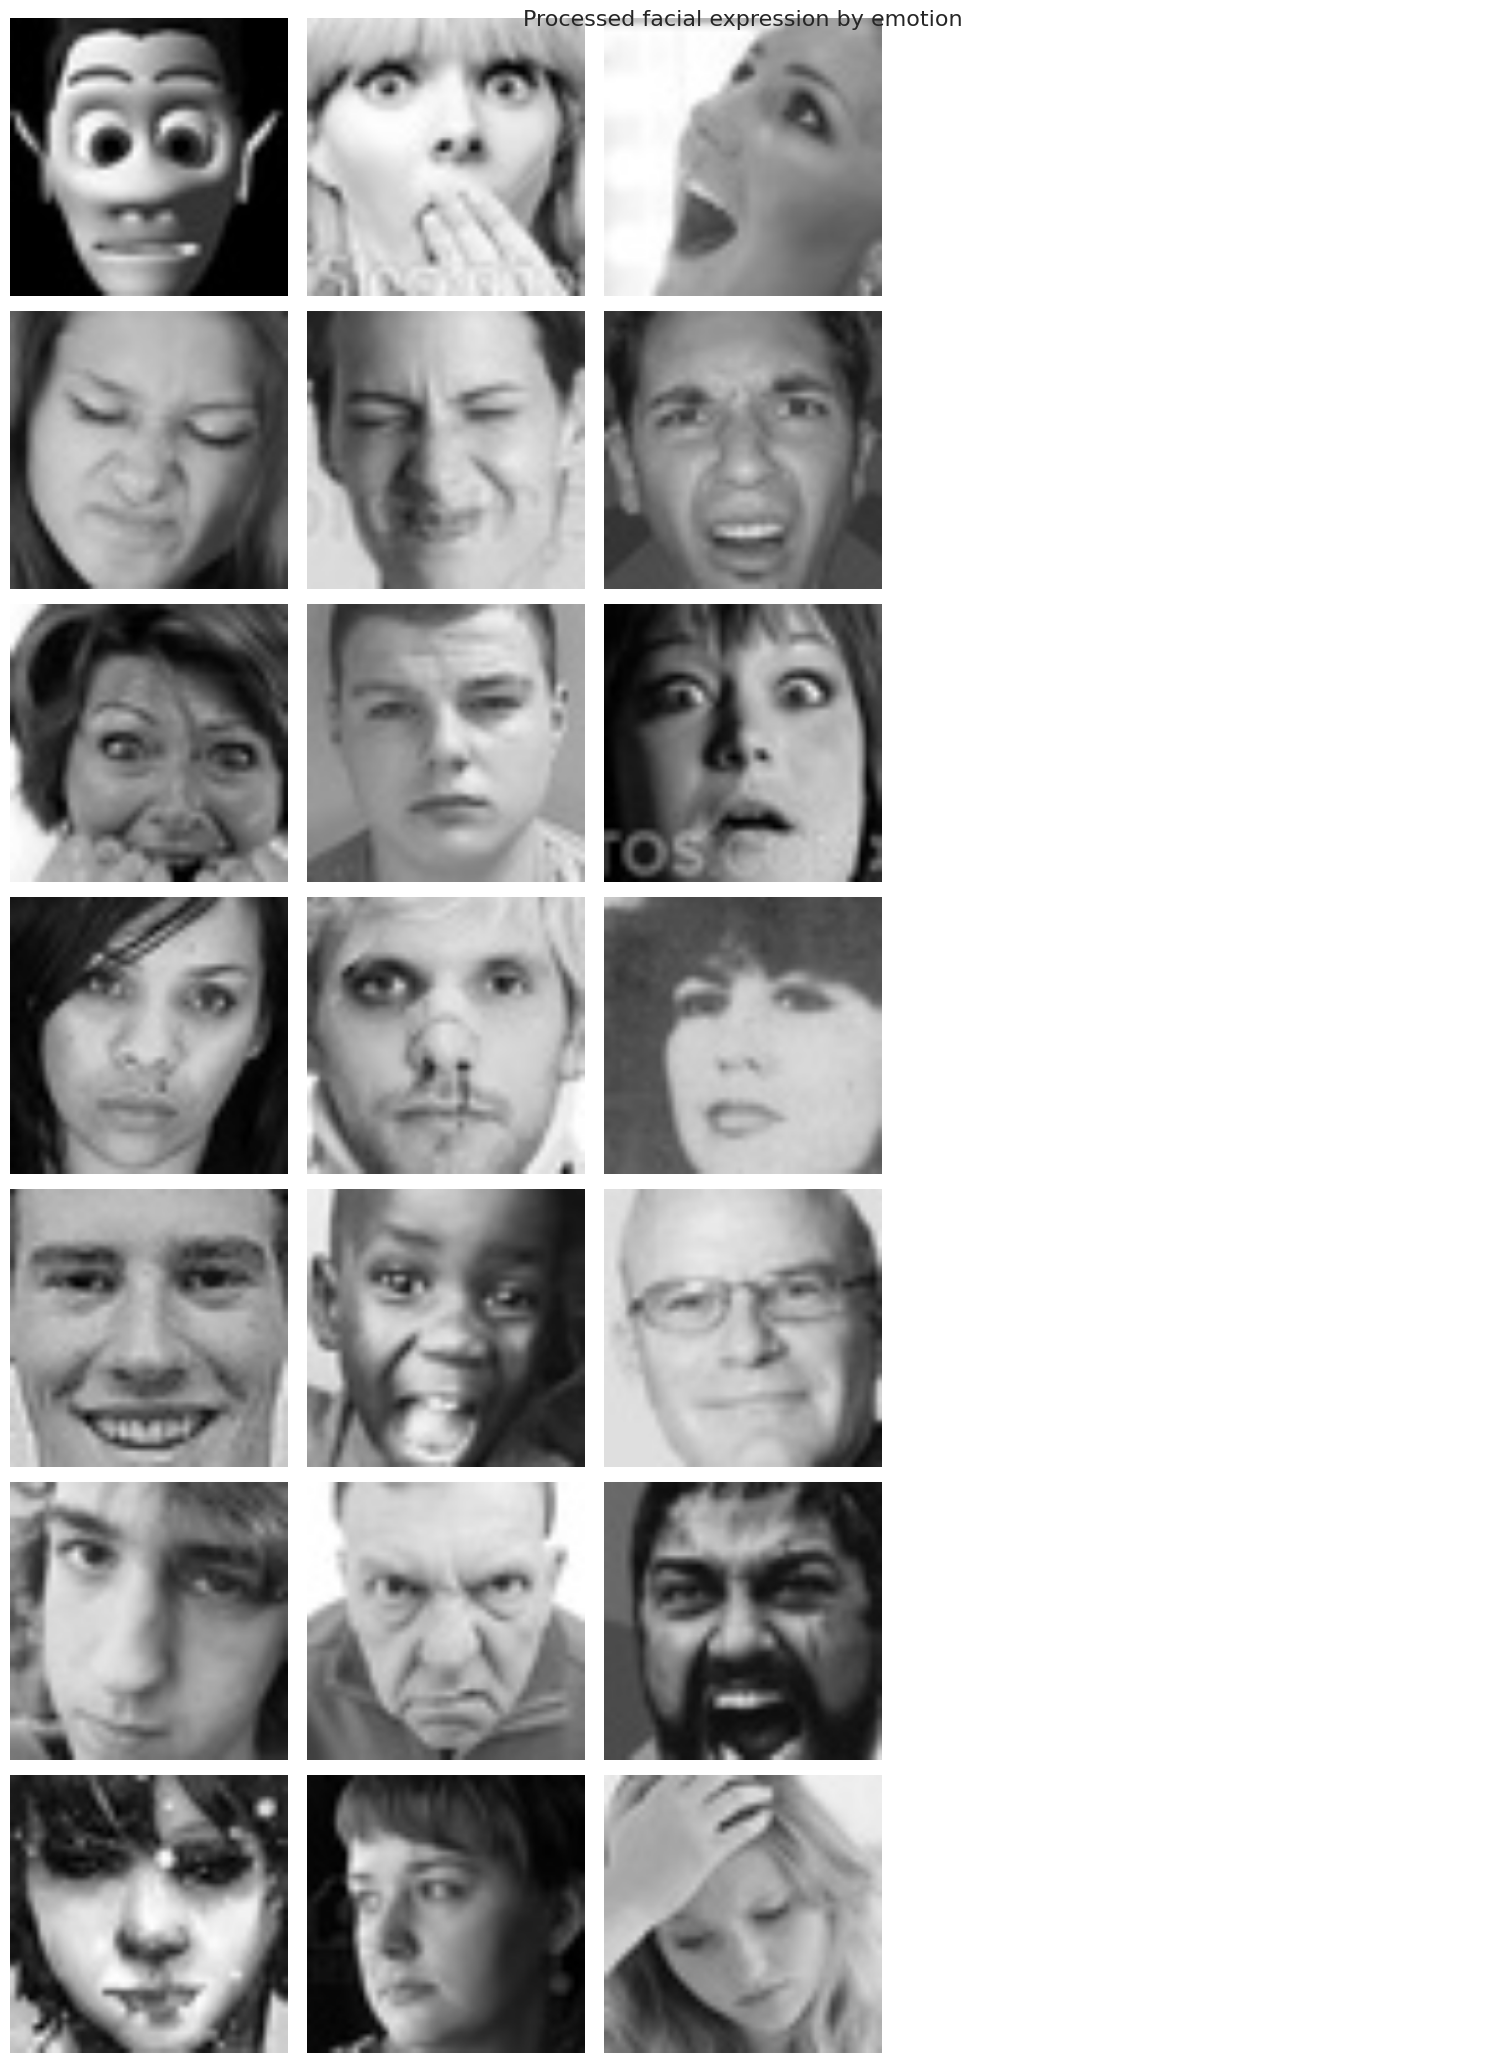

Landmark Extraction Statistics:
 With landmarks: 18
 Without landmarks: 3
 Success rate: 85.7%
 Total augmentations: 189
 Average per image: 9.0


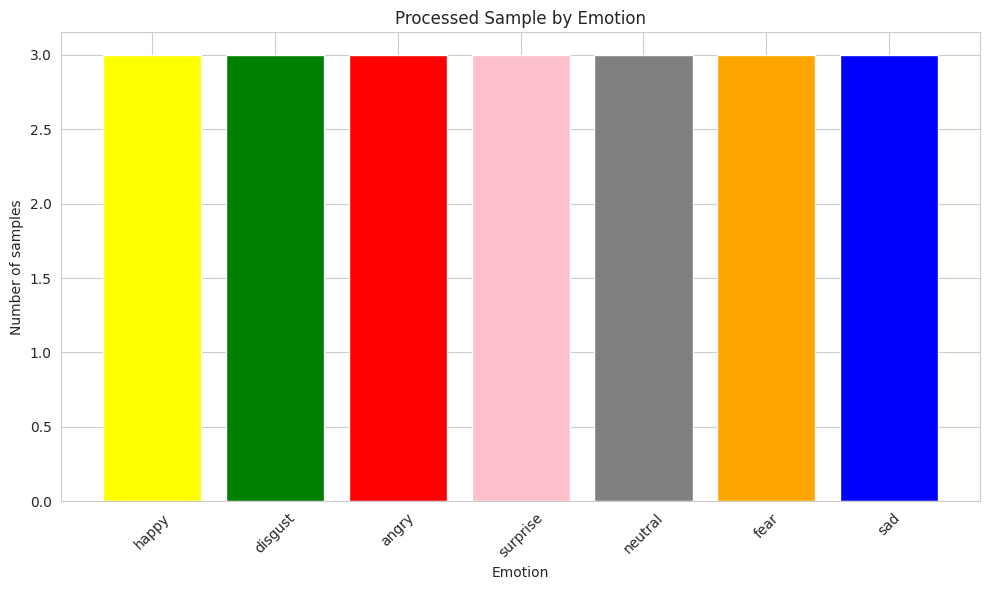

In [21]:
available_emotions = list(set(item['emotion'] for item in BATCH_PROCESSED_DATA))

fig, axes = plt.subplots(len(available_emotions), 5, figsize=(15, len(available_emotions) * 3))

# Handling single row cases
if len(available_emotions) == 1:
    axes = [axes]

for row_idx, emotion in enumerate(available_emotions):
    emotion_samples = [p for p in BATCH_PROCESSED_DATA if p['emotion'] == emotion]

    for col_idx in range(5):
        if col_idx < len(emotion_samples):
            img = emotion_samples[col_idx]['image']
            axes[row_idx][col_idx].imshow(cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2RGB))
            axes[row_idx][col_idx].axis('off')

            if col_idx == 0:
                axes[row_idx][col_idx].set_ylabel(emotion, fontsize=12, rotation=0, ha='right', va='center')
            
        else:
            axes[row_idx][col_idx].axis('off')

plt.suptitle('Processed facial expression by emotion', fontsize=16)
plt.tight_layout()
plt.show()

# Analyze landmark availability
landmark_stats = {
    'with_landmarks': 0,
    'without_landmarks': 0
}

for sample in BATCH_PROCESSED_DATA:
    if sample['landmarks'] is not None:
        landmark_stats['with_landmarks'] += 1
    else:
        landmark_stats['without_landmarks'] += 1

print(f"Landmark Extraction Statistics:")
print(f" With landmarks: {landmark_stats['with_landmarks']}")
print(f" Without landmarks: {landmark_stats['without_landmarks']}")
print(f" Success rate: {landmark_stats['with_landmarks']/len(BATCH_PROCESSED_DATA)*100:.1f}%")


# Augmentation statistics
total_augmentations = sum(len(sample['augmented']) for sample in BATCH_PROCESSED_DATA)
avg_augmentations = total_augmentations / len(BATCH_PROCESSED_DATA)

print(f" Total augmentations: {total_augmentations}")
print(f" Average per image: {avg_augmentations:.1f}")

# Showing emotion distribution plot
emotion_counts = {}
for sample in BATCH_PROCESSED_DATA:
    emotion = sample['emotion']
    emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1

plt.figure(figsize=(10, 6))
emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())
colors = [emotion_colors.get(emotion, 'grey') for emotion in emotions]

plt.bar(emotions, counts, color=colors)
plt.title('Processed Sample by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Complete Dataset processing

In [22]:
def process_complete_dataset(max_samples_per_emotion = None):
    train_path = fer_base_path / "train"
    test_path = fer_base_path / "test"

    processed_data = []
    failed_count = 0

    # process train and test folders
    for split_name, split_path in [("train", train_path), ("test", test_path)]:
        if not split_path.exists():
            continue
        for emotion_folder in split_path.iterdir():
            if not emotion_folder.is_dir() or emotion_folder.name not in fer_emotions.values():
                continue

            emotion_name = emotion_folder.name
            images = list(emotion_folder.glob("*.jpg")) + list(emotion_folder.glob("*.png"))

            if max_samples_per_emotion:
                images = images[:max_samples_per_emotion]

            print(f" Processing {emotion_name}: {len(images)} images")

            for idx, img_path in enumerate(tqdm(images, desc=f"{split_name}-{emotion_name}")):
                try:
                    image = cv2.imread(str(img_path))
                    if image is None:
                        failed_count += 1
                        continue

                    # resize image
                    image_resized = cv2.resize(image, config.IMAGE_SIZE)

                    # Save processed image
                    output_filename = f"fer_2013_{split_name}_{emotion_name}_{idx:04d}.jpg"
                    output_path = PROCESSED_FACIAL_DIR / output_filename
                    cv2.imwrite(str(output_path), image_resized)

                    # Extracting landmark
                    landmarks = extract_facial_landmark(image_resized, show_visualization=False)

                    # Store metadata
                    sample_data = {
                        'file_id': f"{split_name}_{emotion_name}_{idx:04d}",
                        'dataset': 'FER-2013',
                        'emotion': emotion_name,
                        'emotion_code': emotion_to_code.get(emotion_name, -1),
                        'split': split_name,
                        'original_path': str(img_path),
                        'processed_path': str(output_path),
                        'landmarks': landmarks.tolist() if landmarks is not None else None,
                        'image_shape': list(config.IMAGE_SIZE) + [3],
                        'has_landmarks': landmarks is not None
                    }

                    processed_data.append(sample_data)

                except Exception as e:
                    failed_count += 1
                    logger.error(f"Error processing {img_path}: {e}")
                    continue

    print(f"\n Processing results:")
    print(f"Processed: {len(processed_data)}")
    print(f"Failed: {failed_count}")

    # showing distribution
    emotion_counts = {}
    split_counts = {}

    for sample in processed_data:
        emotion = sample['emotion']
        split = sample['split']

        emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1
        split_counts[split] = split_counts.get(split, 0) + 1

    print(f"Distribution by emotion: {emotion_counts}")
    print(f"Distribution by split: {split_counts}")

    return processed_data



In [23]:
complete_processed = process_complete_dataset(max_samples_per_emotion=100)

if complete_processed:
    print(f"Processing complete!")
    print(f" Total samples processed: {len(complete_processed)}")
    COMPLETE_PROCESSED_DATA = complete_processed
else:
    print("Complete processing failed.")

 Processing happy: 100 images


train-happy:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761940744.035066     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940744.039212    2657 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940744.040468    2631 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940744.053156    2629 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761940744.063679     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940744.067555    2686 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940744.068868    2670 infe

 Processing disgust: 100 images


train-disgust:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761940746.611317     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940746.615655    5563 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940746.617850    5537 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940746.627095    5535 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761940746.638329     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940746.642389    5592 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940746.643783    5565 in

 Processing angry: 100 images


...

 Processing fear: 100 images


test-fear:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761940774.623500     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940774.628214   37550 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940774.629579   37524 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940774.635813   37533 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761940774.646076     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940774.650776   37579 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940774.652046   37554 infere

 Processing sad: 100 images


test-sad:   0%|          | 0/100 [00:00<?, ?it/s]I0000 00:00:1761940777.145811     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940777.150488   40462 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940777.153622   40437 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1761940777.162811   40435 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1761940777.174001     952 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1761940777.178003   40491 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1761940777.180225   40465 inferen


 Processing results:
Processed: 1400
Failed: 0
Distribution by emotion: {'happy': 200, 'disgust': 200, 'angry': 200, 'surprise': 200, 'neutral': 200, 'fear': 200, 'sad': 200}
Distribution by split: {'train': 700, 'test': 700}
Processing complete!
 Total samples processed: 1400


### (70-30) split of dataset

In [24]:
from sklearn.model_selection import train_test_split
all_data = complete_processed

train_data, test_data = train_test_split(
    all_data, test_size=0.3,
    stratify=[d['emotion'] for d in all_data],
    random_state=42
)

print(f"Length of train data: {len(train_data)}, Length of test data: {len(test_data)}")

Length of train data: 980, Length of test data: 420


### Metadata creation

In [26]:
def facial_metadata(processed_data):
    summary = {
        'processing_timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
        'total_samples': len(processed_data),
        'dataset_info': {
            'name': 'FER-2013',
            'description': 'Facial Expression Recognition',
            'emotions': list(fer_emotions.values()),
            'total_emotions': len(fer_emotions),
            'format': 'folder_structure'
        },
        'processing_config': {
            'image_size': config.IMAGE_SIZE,
            'face_detection_confidence': config.FACE_DETECTION_CONFIDENCE,
            'augmentation_enabled': config.ENABLE_AUGMENTATION,
            'face_padding': config.FACE_PADDING
        },
        'statistics': {}
    }

    # statistics calculation
    emotion_counts = {}
    split_counts = {}
    landmark_success = 0

    for sample in processed_data:
        emotion = sample['emotion']
        split = sample.get('split', 'unknown')

        emotion_counts[emotion] = emotion_counts.get(emotion, 0) + 1
        split_counts[split] = split_counts.get(split, 0) + 1

        if sample.get('has_landmarks', False):
            landmark_success += 1

    summary['statistics'] = {
        'emotions': emotion_counts,
        'splits': split_counts,
        'landmark_extraction_rate': f"{landmark_success/len(processed_data)*100:.1f}%",
        'landmark_success_count': landmark_success,
        'total_processed_images': len(list(PROCESSED_FACIAL_DIR.glob("*.jpg")))
    }

    # Saved metadata
    metadata_file = METADATA_DIR / "fer_facial_metadata.json"
    with open(metadata_file, 'w') as f:
        json.dump({
            'summary': summary,
            'samples': processed_data
        }, f, indent=2)

    print(f" Metadata saved: {metadata_file}")

    # CSV summary
    csv_data = []
    for sample in processed_data:
        csv_data.append({
            'file_id': sample['file_id'],
            'emotion': sample['emotion'],
            'emotion_code': sample['emotion_code'],
            'split': sample['split'],
            'has_landmarks': sample['has_landmarks'],
            'processed_path': sample['processed_path'],
            'original_path': sample['original_path']
        })

    csv_df = pd.DataFrame(csv_data)
    csv_file = METADATA_DIR / 'fer_summary.csv'
    csv_df.to_csv(csv_file, index = False)

    print(f" Shape: {csv_df.shape}")

    # creating processing summary
    processing_summary = {
        'project': 'Multimodal Mental Health AI - Facial Processing',
        'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
        'dataset': 'FER-2013',
        'total_files_processed': len(processed_data),
        'emotions_covered': list(emotion_counts.keys()),
        'splits_processed': list(split_counts.keys()),
        'output_files': {
            'metadata': str(metadata_file),
            'summary_csv': str(csv_file),
            'processed_images_dir': str(PROCESSED_FACIAL_DIR)
        }
    }

    summary_file = METADATA_DIR / "facial_summary.json"
    with open(summary_file, 'w') as f:
        json.dump(processing_summary, f, indent=2)

    print(f"\n Summary Statistics:")
    print(f" Total: {summary['total_samples']}")
    print(f" Emotions: {emotion_counts}")
    print(f" Splits: {split_counts}")
    print(f" Landmark Success: {landmark_success}/{len(processed_data)} ({landmark_success/len(processed_data)*100:.1f}%)")

    return summary

In [27]:
metadata_summary = facial_metadata(COMPLETE_PROCESSED_DATA)

 Metadata saved: multimodal_facial_data/metadata/fer_facial_metadata.json
 Shape: (1400, 7)

 Summary Statistics:
 Total: 1400
 Emotions: {'happy': 200, 'disgust': 200, 'angry': 200, 'surprise': 200, 'neutral': 200, 'fear': 200, 'sad': 200}
 Splits: {'train': 700, 'test': 700}
 Landmark Success: 1250/1400 (89.3%)
